In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

df = pd.read_csv(r'C:\DATA ANALYSIS AND DATA SCIENCE PROJECTS\Multi Scale Energy Stress Analysis\data\forecasting_feature_set.csv')

df['target'] = df['net_load_mw'].shift(-1)
df = df.dropna().reset_index(drop=True)

split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df  = df.iloc[split_index:]

X_train = train_df.drop(columns=['target'])
y_train = train_df['target']

X_test = test_df.drop(columns=['target'])
y_test = test_df['target']

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

model = LinearRegression()

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

epsilon = 1e-6
mape = np.mean(np.abs((y_test - y_pred) / (y_test + epsilon))) * 100

print("LINEAR REGRESSION PERFORMANCE METRICS")

print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%")

errors = y_test - y_pred
print("\nError Summary:")
print(f"Mean Error      : {np.mean(errors):.4f}")
print(f"Std Error       : {np.std(errors):.4f}")
print(f"Max Error       : {np.max(np.abs(errors)):.4f}")

LINEAR REGRESSION PERFORMANCE METRICS
RMSE : 255.9878
MAE  : 162.0943
R²   : 0.9983
MAPE : 0.91%

Error Summary:
Mean Error      : -8.2861
Std Error       : 255.8536
Max Error       : 3435.0773


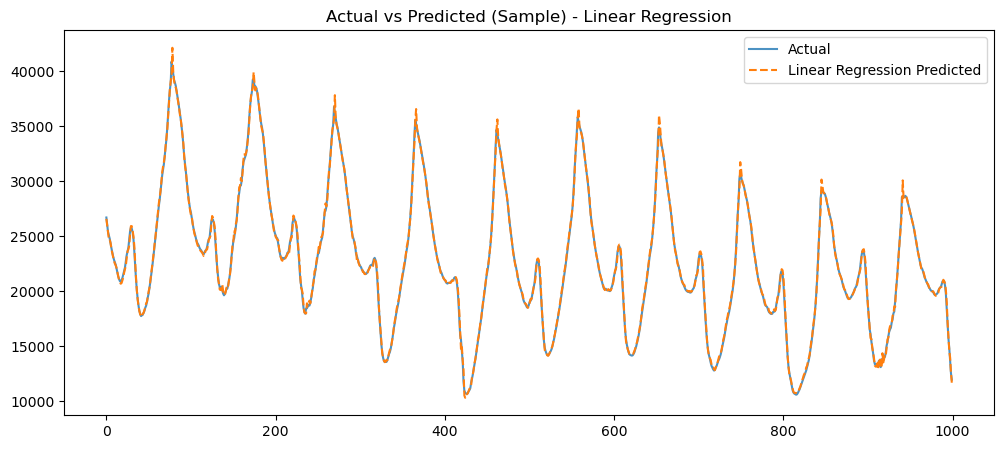

In [2]:
start = 10000
end = 11000

plt.figure(figsize=(12, 5))
plt.plot(y_test.values[start:end], label="Actual", alpha = 0.8)
plt.plot(y_pred[start:end], label="Linear Regression Predicted", linestyle = '--')
plt.title("Actual vs Predicted (Sample) - Linear Regression")
plt.legend()
plt.show()

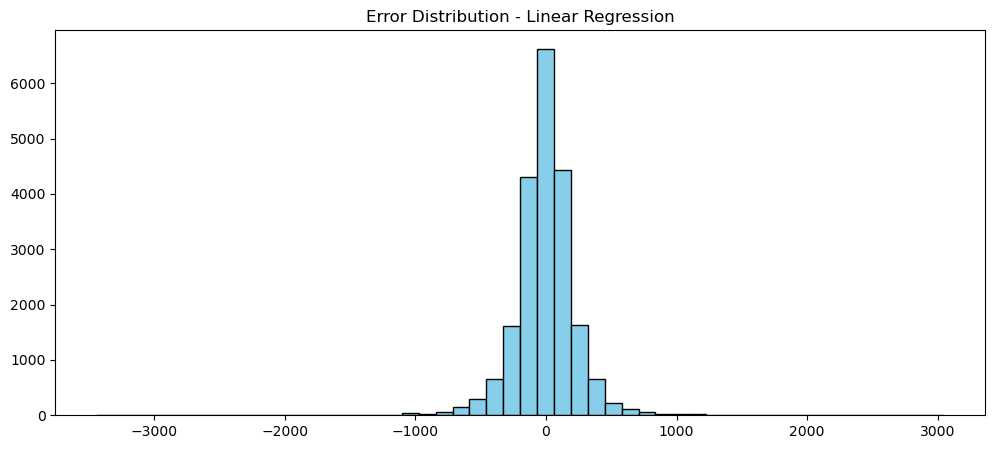

In [3]:
plt.figure(figsize=(12, 5))
plt.hist(errors, bins=50, color = 'skyblue', edgecolor = 'black')
plt.title("Error Distribution - Linear Regression")
plt.show()

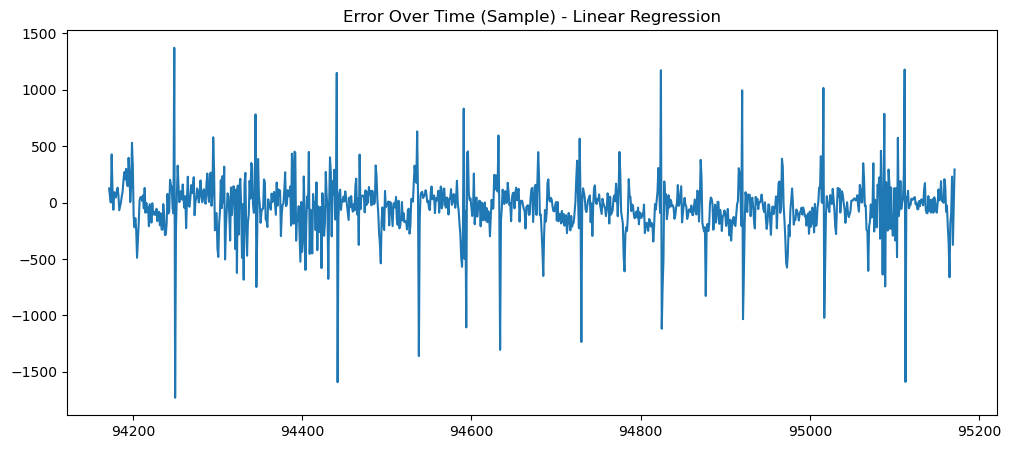

In [4]:
plt.figure(figsize=(12, 5))
plt.plot(errors[start:end])
plt.title("Error Over Time (Sample) - Linear Regression")
plt.show()